# Fase 3: Data cleaning
---
En esta etapa, transformamos el dataset original listings.csv para obtener una versión refinada y centrada en el periodo de interés (2025). El objetivo es asegurar la calidad de los datos antes del análisis.

## 1. Carga de librerías y datos



In [1]:
import pandas as pd
import numpy as np

# Cargamos el dataset original para documentar el punto de partida
df_original = pd.read_csv("../../src/data/listings.csv")

print(f"Registros originales: {len(df_original)}")

Registros originales: 9714


En este primer punto se evaluaría la necesidad de unir tablas. 

Tras analizar el dataset original listings.csv, se confirma que este ya integra las métricas principales necesarias para el análisis (precio, ubicación, disponibilidad y última reseña), por lo que procedemos directamente con este conjunto de datos consolidado, filtrándolo para el año 2025.

No obstante, disponemos también de un segundo dataset mucho más completo, con un gran número de columnas adicionales. Aunque muchas de estas variables no aportan valor directo a nuestro estudio y se descartan, sí resulta útil incorporar dos columnas clave procedentes de ese dataset ampliado:

accommodates → capacidad del alojamiento

review_scores_rating → valoración global del alojamiento

Ambas variables enriquecen significativamente el análisis, ya que permiten estudiar la relación entre capacidad, precio, calidad percibida y distribución por barrios.

In [2]:
# Exploración inicial 
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 9714 entries, 0 to 9713
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              9714 non-null   int64  
 1   name                            9714 non-null   str    
 2   host_id                         9714 non-null   int64  
 3   host_name                       9714 non-null   str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   9714 non-null   str    
 6   latitude                        9714 non-null   float64
 7   longitude                       9714 non-null   float64
 8   room_type                       9714 non-null   str    
 9   price                           8815 non-null   float64
 10  minimum_nights                  9714 non-null   int64  
 11  number_of_reviews               9714 non-null   int64  
 12  last_review                     8709 non-null

In [3]:
df_original.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,96033,"Bonito piso a 200m de la playa, El Palo (Málaga)",510467,Rafael,NaN,Este,36.720310,-4.356270,Entire home/apt,58.0,3,274,2025-09-29,1.88,1,324,40,ESFCTU0000290200003588210000000000000000VUT/MA...
1,166473,Perfect Location In Malaga,793360,Fred,NaN,Este,36.720310,-4.361080,Private room,28.0,5,102,2025-03-27,0.59,5,288,3,NaN
2,330760,Malaga Lodge Guesthouse Double room-shared bath.,1687526,Mayte,NaN,Centro,36.729786,-4.413462,Private room,60.0,1,68,2025-09-04,0.41,6,64,12,ESHFTU0000290200004234200060000000000000VFT/MA...
3,340024,NEW APARTMENT IN MALAGA CENTER,1725690,Carlos,NaN,Centro,36.728130,-4.414220,Entire home/apt,61.0,3,322,2025-09-09,2.11,1,297,38,VFT/MA/02334
4,358541,Casa La Maga - Apartment for happy people,1526932,Cristina,NaN,Centro,36.723740,-4.421300,Entire home/apt,87.0,2,405,2025-07-27,2.48,1,195,23,VFT/MA/02288


In [5]:
# cargamos el nuevo dataset para añadir las columnas que nos interesan

df_detallado = pd.read_csv("../../src/data/detallado.csv.gz")

# seleccionamos las columnas que queremos añadir al antiguo
df_extra = df_detallado[['id', 'accommodates', 'review_scores_rating']]

# Hacemos el merge con tu dataset antiguo
df_final = df_original.merge(df_extra, on='id', how='left')

In [6]:
# Hacemos una segunda exploración del dataset completo

df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 9714 entries, 0 to 9713
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              9714 non-null   int64  
 1   name                            9714 non-null   str    
 2   host_id                         9714 non-null   int64  
 3   host_name                       9714 non-null   str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   9714 non-null   str    
 6   latitude                        9714 non-null   float64
 7   longitude                       9714 non-null   float64
 8   room_type                       9714 non-null   str    
 9   price                           8815 non-null   float64
 10  minimum_nights                  9714 non-null   int64  
 11  number_of_reviews               9714 non-null   int64  
 12  last_review                     8709 non-null

## 2. Eliminar columnas (Feature Selection)

In [7]:
# Creamos el nuevo 2025 que vamos a ir filtrando

# Eliminamos las columnas previamente seleccionadas

df_2025 = df_final.drop(columns=["neighbourhood_group", "latitude", "longitude"])

# Realizamos un estudio de cardinalidades:
cardinalidades = {}
for column in df_2025:
    cardinalidad = len(df_2025[column].unique())/len(df_2025)*100
    cardinalidades[column] = round(cardinalidad, 2)
    print(f"La cardinalidad de la columna {column} es de {cardinalidad:.2f}")
    
cardinalidades

La cardinalidad de la columna id es de 100.00
La cardinalidad de la columna name es de 97.19
La cardinalidad de la columna host_id es de 36.07
La cardinalidad de la columna host_name es de 17.23
La cardinalidad de la columna neighbourhood es de 0.11
La cardinalidad de la columna room_type es de 0.04
La cardinalidad de la columna price es de 5.41
La cardinalidad de la columna minimum_nights es de 0.44
La cardinalidad de la columna number_of_reviews es de 4.63
La cardinalidad de la columna last_review es de 9.54
La cardinalidad de la columna reviews_per_month es de 6.85
La cardinalidad de la columna calculated_host_listings_count es de 0.59
La cardinalidad de la columna availability_365 es de 3.77
La cardinalidad de la columna number_of_reviews_ltm es de 1.26
La cardinalidad de la columna license es de 74.08
La cardinalidad de la columna accommodates es de 0.16
La cardinalidad de la columna review_scores_rating es de 1.61


{'id': 100.0,
 'name': 97.19,
 'host_id': 36.07,
 'host_name': 17.23,
 'neighbourhood': 0.11,
 'room_type': 0.04,
 'price': 5.41,
 'minimum_nights': 0.44,
 'number_of_reviews': 4.63,
 'last_review': 9.54,
 'reviews_per_month': 6.85,
 'calculated_host_listings_count': 0.59,
 'availability_365': 3.77,
 'number_of_reviews_ltm': 1.26,
 'license': 74.08,
 'accommodates': 0.16,
 'review_scores_rating': 1.61}

In [8]:
df_2025.info()

<class 'pandas.DataFrame'>
RangeIndex: 9714 entries, 0 to 9713
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              9714 non-null   int64  
 1   name                            9714 non-null   str    
 2   host_id                         9714 non-null   int64  
 3   host_name                       9714 non-null   str    
 4   neighbourhood                   9714 non-null   str    
 5   room_type                       9714 non-null   str    
 6   price                           8815 non-null   float64
 7   minimum_nights                  9714 non-null   int64  
 8   number_of_reviews               9714 non-null   int64  
 9   last_review                     8709 non-null   str    
 10  reviews_per_month               8709 non-null   float64
 11  calculated_host_listings_count  9714 non-null   int64  
 12  availability_365                9714 non-null

In [9]:
# Utilizaremos la columna id como índice ya que tiene una cardinalidad del 100%
df_2025.set_index("id", inplace=True)

## 3. Formato de los datos (Data Types)

In [10]:
# Convertir 'last_review' a formato fecha
df_2025['last_review'] = pd.to_datetime(df_2025['last_review'], format='%Y-%m-%d')

# Filtramos para quedarnos con los registros relativos a 2025
df_2025 = df_2025[df_2025["last_review"].dt.year == 2025]

In [11]:
# Verificamos que los tipo de datos sean los correctos
print("\nEsquema de datos final:")
df_2025.info()


Esquema de datos final:
<class 'pandas.DataFrame'>
Index: 7338 entries, 96033 to 1513513040075120429
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   name                            7338 non-null   str           
 1   host_id                         7338 non-null   int64         
 2   host_name                       7338 non-null   str           
 3   neighbourhood                   7338 non-null   str           
 4   room_type                       7338 non-null   str           
 5   price                           6861 non-null   float64       
 6   minimum_nights                  7338 non-null   int64         
 7   number_of_reviews               7338 non-null   int64         
 8   last_review                     7338 non-null   datetime64[us]
 9   reviews_per_month               7338 non-null   float64       
 10  calculated_host_listings_count  7338 non-nul

In [12]:
df_2025.head(2)

,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,accommodates,review_scores_rating
id,,,,,,,,,,,,,,,,
96033,"Bonito piso a 200m de la playa, El Palo (Málaga)",510467,Rafael,Este,Entire home/apt,58.0,3,274,2025-09-29,1.88,1,324,40,ESFCTU0000290200003588210000000000000000VUT/MA...,3,4.61
166473,Perfect Location In Malaga,793360,Fred,Este,Private room,28.0,5,102,2025-03-27,0.59,5,288,3,NaN,1,4.73


## 4. Valores nulos (Missing values)

In [13]:
# Resumen de valores nulos
print("\n--- Conteo de valores nulos ---")
print(df_2025.isnull().sum())


--- Conteo de valores nulos ---
name                                0
host_id                             0
host_name                           0
neighbourhood                       0
room_type                           0
price                             477
minimum_nights                      0
number_of_reviews                   0
last_review                         0
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
number_of_reviews_ltm               0
license                            56
accommodates                        0
review_scores_rating                0
dtype: int64


In [24]:
# Eliminamos las filas que presentan precios nulos ya que suponen un del 6.5% del total.
df_2025 = df_2025.dropna(subset=["price"])

print("\n--- Conteo de valores nulos tras limpieza de nulos ---")
print(df_2025.isnull().sum())


--- Conteo de valores nulos tras limpieza de nulos ---
name                               0
host_id                            0
host_name                          0
neighbourhood                      0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                        0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
number_of_reviews_ltm              0
license                           55
accommodates                       0
review_scores_rating               0
estancia_clasificacion             0
disponibilidad_clasificacion       0
host_type                          0
Segmento Reseñas                   0
dtype: int64


### Licencias nulas en el dataset

Tras la limpieza del dataset, todas las variables relevantes quedan sin valores nulos, excepto la columna **`license`**, que mantiene 55 registros vacíos. Decidimos conservar estos valores nulos por dos motivos principales:

1. **La ausencia de licencia es una información relevante en sí misma.**  
   En el mercado de alquiler turístico, que un alojamiento no declare licencia puede indicar:
   - falta de regularización  
   - actividad informal  
   - menor control administrativo  

   Esta característica puede influir en variables como el precio, la disponibilidad o la valoración del alojamiento.

2. **Permite comparar el comportamiento entre alojamientos con y sin licencia.**  
   Mantener los nulos nos permite analizar si existen diferencias significativas, por ejemplo:
   - ¿Los alojamientos sin licencia son más baratos?  
   - ¿Tienen mayor disponibilidad?  
   - ¿Reciben peores valoraciones?  

Por tanto, **no imputamos ni eliminamos estos valores**, ya que su ausencia no es un error del dataset, sino una característica que aporta información útil para el análisis.


## 5. Valores atípicos (Outliers)

Debemos identificar valores atípicos que puedan sesgar nuestro análisis, especialmente en variables críticas como el precio y el mínimo de noches. Los outliers no siempre son errores, así que los detectaremos y estudiaremos para tomar la mejor decisión.

In [14]:
# Usamos describe para ver máximos y mínimos sospechosos
print("Resumen estadístico de variables numéricas:")
df_2025[['price', 'minimum_nights', 'number_of_reviews']].describe()

Resumen estadístico de variables numéricas:


,price,minimum_nights,number_of_reviews
count,6861.000000,7338.000000,7338.000000
mean,199.602973,2.863859,63.482829
std,885.409832,9.799997,90.548770
min,18.000000,1.000000,1.000000
25%,75.000000,1.000000,9.000000
50%,99.000000,2.000000,29.000000
75%,137.000000,3.000000,79.000000
max,21911.000000,365.000000,1110.000000


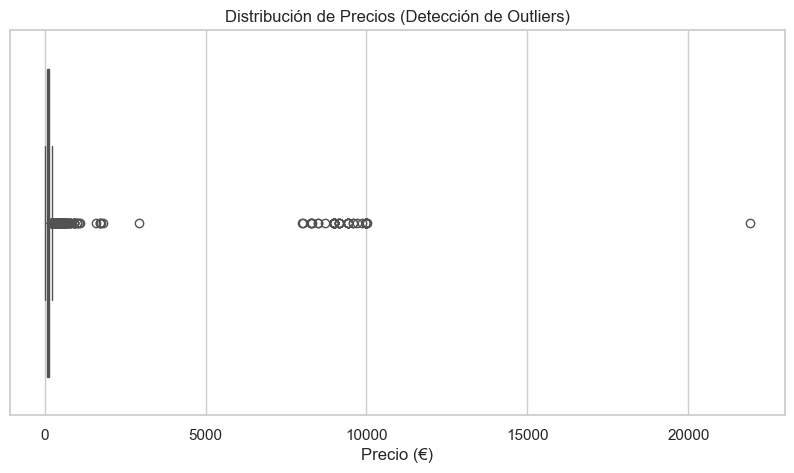

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Creamos un gráfico de caja para el Precio
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_2025['price'], color='#4ab8c8')
plt.title('Distribución de Precios (Detección de Outliers)')
plt.xlabel('Precio (€)')
plt.show()

Como se aprecia en el Boxplot anterior, existe un sesgo extremo en la variable price. La presencia de valores atípicos por encima de los 4.000€ impide observar la distribución de la mayoría de la oferta. Procedemos a filtrar la visualización para entender mejor el mercado real.

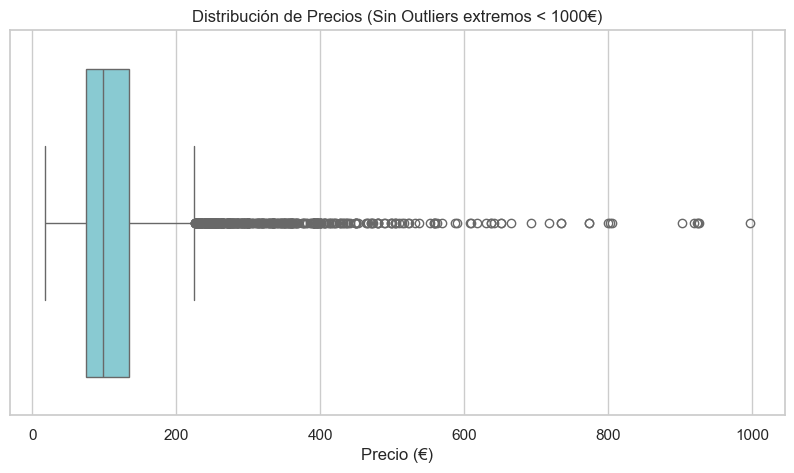

Registros totales: 7338
Registros con precio > 1000€: 69


In [16]:
# Filtramos temporalmente para el gráfico (por ejemplo, precios menores a 1000€)
df_filtrado_precio = df_2025[df_2025['price'] < 1000]

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_filtrado_precio['price'], color='#7dd4de')
plt.title('Distribución de Precios (Sin Outliers extremos < 1000€)')
plt.xlabel('Precio (€)')
plt.show()

print(f"Registros totales: {len(df_2025)}")
print(f"Registros con precio > 1000€: {len(df_2025[df_2025['price'] >= 1000])}")

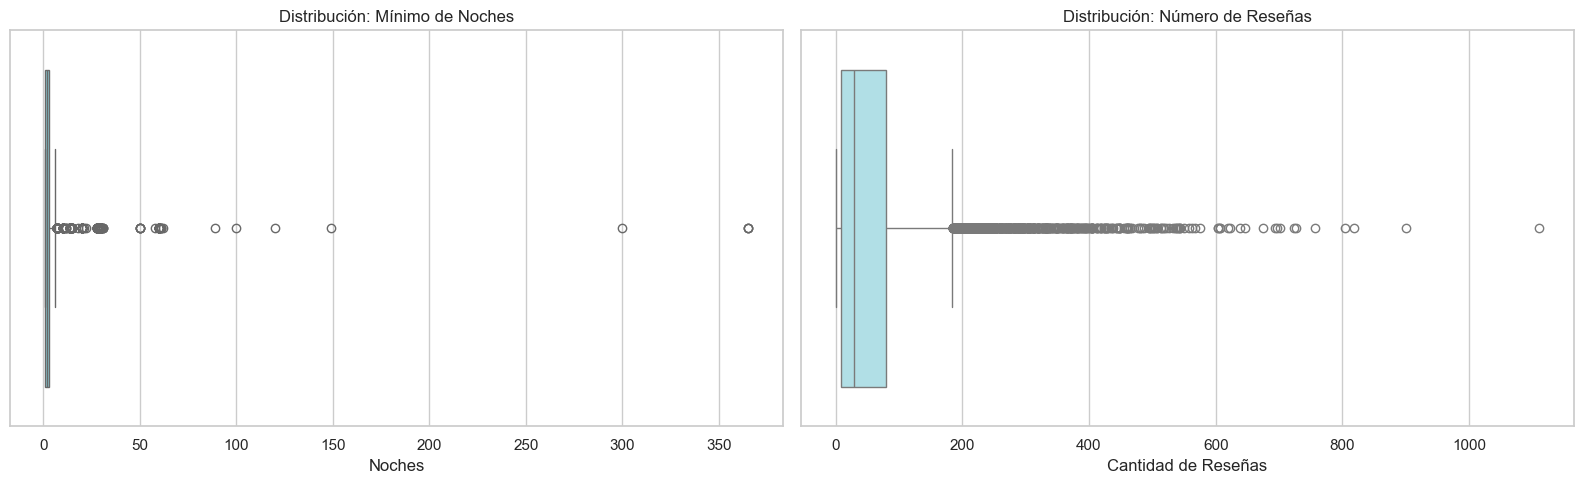

In [17]:
# Configuramos la figura para dos gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Boxplot para Mínimo de Noches
sns.boxplot(x=df_2025['minimum_nights'], ax=ax1, color='#7dd4de')
ax1.set_title('Distribución: Mínimo de Noches')
ax1.set_xlabel('Noches')

# 2. Boxplot para Número de Reseñas
sns.boxplot(x=df_2025['number_of_reviews'], ax=ax2, color='#a8e6ef')
ax2.set_title('Distribución: Número de Reseñas')
ax2.set_xlabel('Cantidad de Reseñas')

plt.tight_layout()
plt.show()

Mínimo de Noches(izquierda): La gran mayoría de los alojamientos en Málaga se sitúan por debajo de las 7 noches. Los valores que vemos extendiéndose hacia la derecha representan casos atípicos (alquileres de larga estancia o bloqueos de calendario) que deben ser tratados para no desvirtuar el análisis del comportamiento turístico.

Número de Reseñas: Se observa una distribución con sesgo positivo muy marcado. Aunque la mayoría de los pisos tienen pocas reseñas, los outliers que superan las 200-400 críticas identifican a los "Veteranos" de la plataforma, aquellos con mayor éxito y rotación histórica.

Decisión sobre el filtrado:
Tras el análisis visual de outliers en price, minimum_nights y number_of_reviews, se ha optado por mantener la totalidad de los registros en el DataFrame actual. Justificación:

- Los valores atípicos en el precio representan el segmento de lujo de Málaga 2025.

- Las estancias mínimas elevadas y el alto volumen de reseñas son comportamientos reales del mercado que podrían ser objeto de estudio específico más adelante.

- En la Fase 4 (Análisis Exploratorio), si alguna visualización se ve distorsionada por estos valores, se aplicarán filtros locales o escalas logarítmicas para facilitar la interpretación sin perder la integridad del dataset original.

## 6. Duplicados (Duplicates)

In [18]:
# Verificación de registros duplicados
duplicados = df_2025.duplicated().sum()
print(f"Número de registros duplicados detectados: {duplicados}")

Número de registros duplicados detectados: 0


## 7. Escalado (Scaling)

Se ha evaluado la necesidad de estandarizar las variables numéricas. Sin embargo, dado que el objetivo de este EDA es la interpretación directa de las métricas de negocio, se ha decidido mantener las escalas originales.

## 8. Transformaciones (Feature Engineering)

In [19]:
# Para analizar si el turismo es de corta, media o larga duración, hemos clasificado el mínimo de noches a reservar en tres grupos: 
# "Corta", "Media" y "Larga".

def clasificar_estancia(x):
    if x <= 7:
        return "Corta"
    elif x <= 29:
        return "Media"
    else:
        return "Larga"

df_2025["estancia_clasificacion"] = df_2025["minimum_nights"].apply(clasificar_estancia)

In [20]:
# Para analizar si la disponibilidad del alojamiento, hemos clasificado la disponibilidad anual en tres grupos: 
# "Baja", "Media" y "Alta".

def clasificar_disponibilidad(x):
    if x <= 90:
        return "Baja"
    elif x <= 180:
        return "Media"
    else:
        return "Alta"

df_2025["disponibilidad_clasificacion"] = df_2025["availability_365"].apply(clasificar_disponibilidad)

In [21]:
# Análisis del tipo de host

def clasificar_host(x):
    if x == 1:
        return "Particular"
    elif x <= 5:
        return "Semi-profesional"
    elif x <= 20:
        return "Profesional"
    else:
        return "Empresa/Hotel"

df_2025["host_type"] = df_2025["calculated_host_listings_count"].apply(clasificar_host)


In [22]:
# Para desarrollar la segunda hipótesis, hemos segmentado el total de las reseñas en tres grupos: "Muchas", "Medias" y "Pocas":
cortes = [0, 10, 50, df_2025['number_of_reviews'].max()]
etiquetas = ['Pocas', 'Medias', 'Muchas']
df_2025['Segmento Reseñas'] = pd.cut(df_2025['number_of_reviews'], bins=cortes, labels=etiquetas, include_lowest=True)

## Resultado de la limpieza

In [25]:
# 1. Comprobación de tipos de datos (Casting check)
print("--- Tipado de datos ---")
print(df_2025.dtypes)

# 2. Resumen de valores nulos
print("\n--- Conteo de valores nulos ---")
print(df_2025.isnull().sum())

# 3. Verificación de duplicados
print(f"\n--- Total de registros duplicados: {df_2025.duplicated().sum()} ---")

# 4. Dimensiones del dataset final (2025)
print(f"\nDimensiones finales del dataset: {df_2025.shape}")

--- Tipado de datos ---
name                                         str
host_id                                    int64
host_name                                    str
neighbourhood                                str
room_type                                    str
price                                    float64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[us]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm                      int64
license                                      str
accommodates                               int64
review_scores_rating                     float64
estancia_clasificacion                       str
disponibilidad_clasificacion                 str
host_type                                    str
Segmento Reseñas                        categ

In [26]:
# Guardamos el DataFrame trabajado en la carpeta src/data
df_2025.to_csv('../data/df_2025.csv', index=False)
print("Exportación completada con éxito.")

Exportación completada con éxito.
